In [11]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

In [24]:
#read counts data
expr = pd.read_csv("SRP_counts.tsv.gz", sep="\t", index_col="Gene")
meta = pd.read_csv("metadata.tsv.gz", sep="\t")

In [2]:
#data stuff
assert list(expr.columns) == meta.refinebio_accession_code.tolist() #make sure samples match in metadata and expr matrix
print("genes x samples:", expr.shape)
#read metadata and separate into brain areas and disorders
meta[["region", "dx"]] = meta.refinebio_subject.str.split("_", n=1, expand=True)
meta["donor"] = meta.refinebio_title.str.split("_").str[0]

print(pd.crosstab(meta.dx, meta.region))
print("unique donors:", meta.donor.nunique())

#each library is the specific patient sample from each region sampled. Here I look for and merged duplicates
run_to_lib = meta.set_index("refinebio_accession_code").refinebio_title
print("duplicate runs:", run_to_lib.duplicated().sum())

expr_lib = expr.T.groupby(run_to_lib).mean().T
meta_lib = (meta.drop_duplicates("refinebio_title").set_index("refinebio_title").loc[expr_lib.columns])

print("genes x libraries:", expr_lib.shape)

#found 69 duplicates, so we actually have 266 libraries total

#5 log-scale the data (the range of data before is to confirm the data is not log-scaled yet, only quantile normalized)
print("range before log:", expr_lib.values.min(), expr_lib.values.max())
log_expr = np.log2(expr_lib + 1)
#we have to add 1 or else log-scaling breaks with the negative values from quantile normalization

#how much variation do you see in the data? (per gene median expression ranges) 
medians = log_expr.median(axis=1)
spread = log_expr.max(axis=1) - log_expr.min(axis=1)

print(medians.describe())
print("genes with median <= 0:", (medians <= 0).sum())
print(spread.describe())

genes x samples: (43363, 335)
region            ancg  dlpfc  nacc
dx                                 
bipolar disorder    25     28    30
control             28     28    27
major depression    27     30    32
schizophrenia       27     28    25
unique donors: 96
duplicate runs: 69
genes x libraries: (43363, 266)
range before log: -0.1583617006285569 197.4761356701856
count    43363.000000
mean         1.092880
std          1.154176
min         -0.098697
25%          0.181527
50%          0.767416
75%          1.723796
max          7.632822
dtype: float64
genes with median <= 0: 8165
count    43363.000000
mean         1.104323
std          0.650898
min          0.341434
25%          0.684684
50%          0.879574
75%          1.260153
max          6.202458
dtype: float64


In [19]:
#convert the Ensembl IDs to gene names with mygene. 
import mygene

mg = mygene.MyGeneInfo()
results = mg.querymany(expr_lib.index.tolist(), scopes="ensembl.gene", fields="symbol", species="human")

res = pd.DataFrame(results)
print("rows returned:", len(res), "vs queried:", len(expr_lib))
print("multi-hit IDs:", res["query"].duplicated().sum())

#there's 28 duplicate names that we need to get rid of or else all the later genes are unmatched because of offset
symbols = (res.drop_duplicates("query")
              .set_index("query")["symbol"]
              .reindex(expr_lib.index))

print("no symbol:", symbols.isna().sum())
symbols.rename("symbol").rename_axis("ensembl_id").to_csv("gene_symbols.tsv", sep="\t")

28 input query terms found dup hits:	[('ENSG00000117262', 2), ('ENSG00000188092', 2), ('ENSG00000188660', 2), ('ENSG00000226506', 2), ('E
1232 input query terms found no hit:	['ENSG00000112096', 'ENSG00000116883', 'ENSG00000130489', 'ENSG00000130723', 'ENSG00000131484', 'ENS


rows returned: 43406 vs queried: 43363
multi-hit IDs: 43
no symbol: 10172


In [21]:
expr_lib.to_csv("data/expr_by_library.tsv.gz", sep="\t")
meta_lib.to_csv("data/meta_by_library.tsv", sep="\t")

In [2]:
expr = pd.read_csv("data/expr_by_library.tsv.gz", sep="\t", index_col=0)
meta = pd.read_csv("data/meta_by_library.tsv", sep="\t", index_col=0)

sl = meta.index.str.extract(r"SL(\d+)")[0].astype(int).values
meta["batch"] = np.where(sl > 20000, "B", "A")

keep = meta[(meta.region == "ancg")].copy()
keep["group"] = np.where(keep.dx == "control", "Control", "Disorder")

#log scale and filter genes with zero expression (about 8000) before doing plots
log_expr = np.log2(expr[keep.index] + 1)
log_expr = log_expr[log_expr.median(axis=1) > 0]

#select 5000 most variable genes 
top = log_expr.var(axis=1).sort_values(ascending=False).index[:5000]
X = log_expr.loc[top].T

## unsupervised analysis
### KMeans 

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
def find_best_k(X):
    k_values = range(2, 21)
    silhouette_scores=[]
    total_labels=[]
    for k in k_values:
        kmeans=KMeans(n_clusters=k,
                      random_state=0,
                      n_init="auto")
        labels=kmeans.fit_predict(X)
        total_labels.append(labels)
        score=silhouette_score(X, labels)
        silhouette_scores.append(score)
    
    best_k=k_values[np.argmax(silhouette_scores)]
    best_labels=total_labels[np.argmax(silhouette_scores)]

    return best_k, max(silhouette_scores), best_labels

In [5]:
### 5000 genes
best_k_5000, best_sil_score_5000, best_labels_5000=find_best_k(X)
print("best k: ", best_k_5000)
print("silhouette score: ", best_sil_score_5000)

best k:  2
silhouette score:  0.3225959449504154


In [11]:
X.index.shape

(89,)

In [19]:
from scipy.stats import chi2_contingency

DX_ORDER = ["control", "major depression", "bipolar disorder", "schizophrenia"]
DX_NAME = {"control": "Control", "major depression": "Depression",
           "bipolar disorder": "Bipolar", "schizophrenia": "Schizophrenia"}

KS = [2, 3, 4, 5]
labels = pd.DataFrame(index=keep.index)
labels.index.name = "refinebio_title"
summary = []
for k in KS:
    kmeans=KMeans(n_clusters=k,
                      random_state=0,
                      n_init="auto")
    lab=kmeans.fit_predict(X)
    labels[f"g5000_k{k}"] = lab
    sizes = np.bincount(lab)[1:]
    summary.append({
        "k": k,
        "cluster_sizes": " / ".join(map(str, sizes)),
        "silhouette": silhouette_score(X, lab),
        "batch_chi2_p": chi2_contingency(pd.crosstab(lab, keep.batch))[1],
    })
    print(f"\n=== k = {k} ===")
    tab = pd.crosstab(lab, keep.dx).reindex(columns=DX_ORDER)
    tab["batch B"] = pd.crosstab(lab, keep.batch).get("B", 0)
    print(tab.rename(columns=DX_NAME).to_string())

summary = pd.DataFrame(summary)
#summary.to_csv("results/a3_hclust_k_summary.tsv", sep="\t", index=False)
summary.round(3)


=== k = 2 ===
dx     Control  Depression  Bipolar  Schizophrenia  batch B
row_0                                                      
0           22          22       15             16       15
1            0           0        7              7        2

=== k = 3 ===
dx     Control  Depression  Bipolar  Schizophrenia  batch B
row_0                                                      
0           13          17        8              8       13
1            9           5        9             11        4
2            0           0        5              4        0

=== k = 4 ===
dx     Control  Depression  Bipolar  Schizophrenia  batch B
row_0                                                      
0            8           8        3              3       15
1            4           2       11             11        2
2            0           0        2              3        0
3           10          12        6              6        0

=== k = 5 ===
dx     Control  Depression  Bipolar  Sch

,k,cluster_sizes,silhouette,batch_chi2_p
0,2,14,0.323,0.897
1,3,34 / 9,0.116,0.055
2,4,28 / 5 / 34,0.107,0.000
3,5,26 / 1 / 32 / 10,0.103,0.000


In [17]:
n_genes=[10, 100, 1000, 10000]
cluster_labels=[]
for n in n_genes:
    top = log_expr.var(axis=1).sort_values(ascending=False).index[:n]
    X = log_expr.loc[top].T

    best_k, best_sil_score, best_labels=find_best_k(X)
    cluster_labels.append(best_labels)

    print("n=", n)
    print("best k: ", best_k)
    print("silhouette score: ", best_sil_score)
    print()

n= 10
best k:  6
silhouette score:  0.18303860101538466

n= 100
best k:  2
silhouette score:  0.2137497441023839

n= 1000
best k:  2
silhouette score:  0.2804513417932182

n= 10000
best k:  2
silhouette score:  0.3161639104053734



### Chi-square on clustering results

In [8]:
from scipy.stats import chi2_contingency
from itertools import combinations

In [18]:
tot_cluster_labels = {
    10: cluster_labels[0],
    100: cluster_labels[1],
    1000: cluster_labels[2],
    10000: cluster_labels[3],
}

In [22]:
results = []

for n_genes_a, n_genes_b in combinations(tot_cluster_labels.keys(), 2):
    contingency = pd.crosstab(
        tot_cluster_labels[n_genes_a],
        tot_cluster_labels[n_genes_b]
    )

    chi2, p_value, dof, expected = chi2_contingency(contingency)

    n_cells = contingency.to_numpy().sum()
    min_dimension = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n_cells * min_dimension))

    results.append({
        "Comparison": f"{n_genes_a} vs {n_genes_b}",
        "Chi-square": chi2,
        "df": dof,
        "p-value": p_value,
        "Minimum expected count": expected.min()
    })

results_df = pd.DataFrame(results)

In [23]:
results_df

,Comparison,Chi-square,df,p-value,Minimum expected count
0,10 vs 100,31.299378,5,8.174777e-06,1.966292
1,10 vs 1000,25.295932,5,1.221457e-04,1.494382
2,10 vs 10000,21.032236,5,7.987782e-04,0.943820
3,100 vs 1000,49.008814,1,2.548149e-12,5.337079
4,100 vs 10000,31.511939,1,1.982178e-08,3.370787
5,1000 vs 10000,45.829673,1,1.289947e-11,2.561798


## Heatmaps and Dendograms

In [33]:
annotations=pd.DataFrame(
    {
        "K-means": best_labels_5000,
        "Sample group": keep['refinebio_subject']
    },
    index=X.index
)
annotations["K-means"] = "KMeans_" + annotations["K-means"].astype(str)
annotations["Sample group"] = annotations["Sample group"].astype(str)

In [35]:
annotation_color_maps = {}
row_color_data = pd.DataFrame(index=annotations.index)

for column in annotations.columns:
    categories = annotations[column].unique()

    # A categorical palette with enough distinct colors
    palette = sns.color_palette("tab20", n_colors=len(categories))

    color_map = dict(zip(categories, palette))
    annotation_color_maps[column] = color_map

    # Map each cell's category to its sidebar color
    row_color_data[column] = annotations[column].map(color_map)

/home/honestkids/miniforge3/envs/bioinfokit-py311/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/honestkids/miniforge3/envs/bioinfokit-py311/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


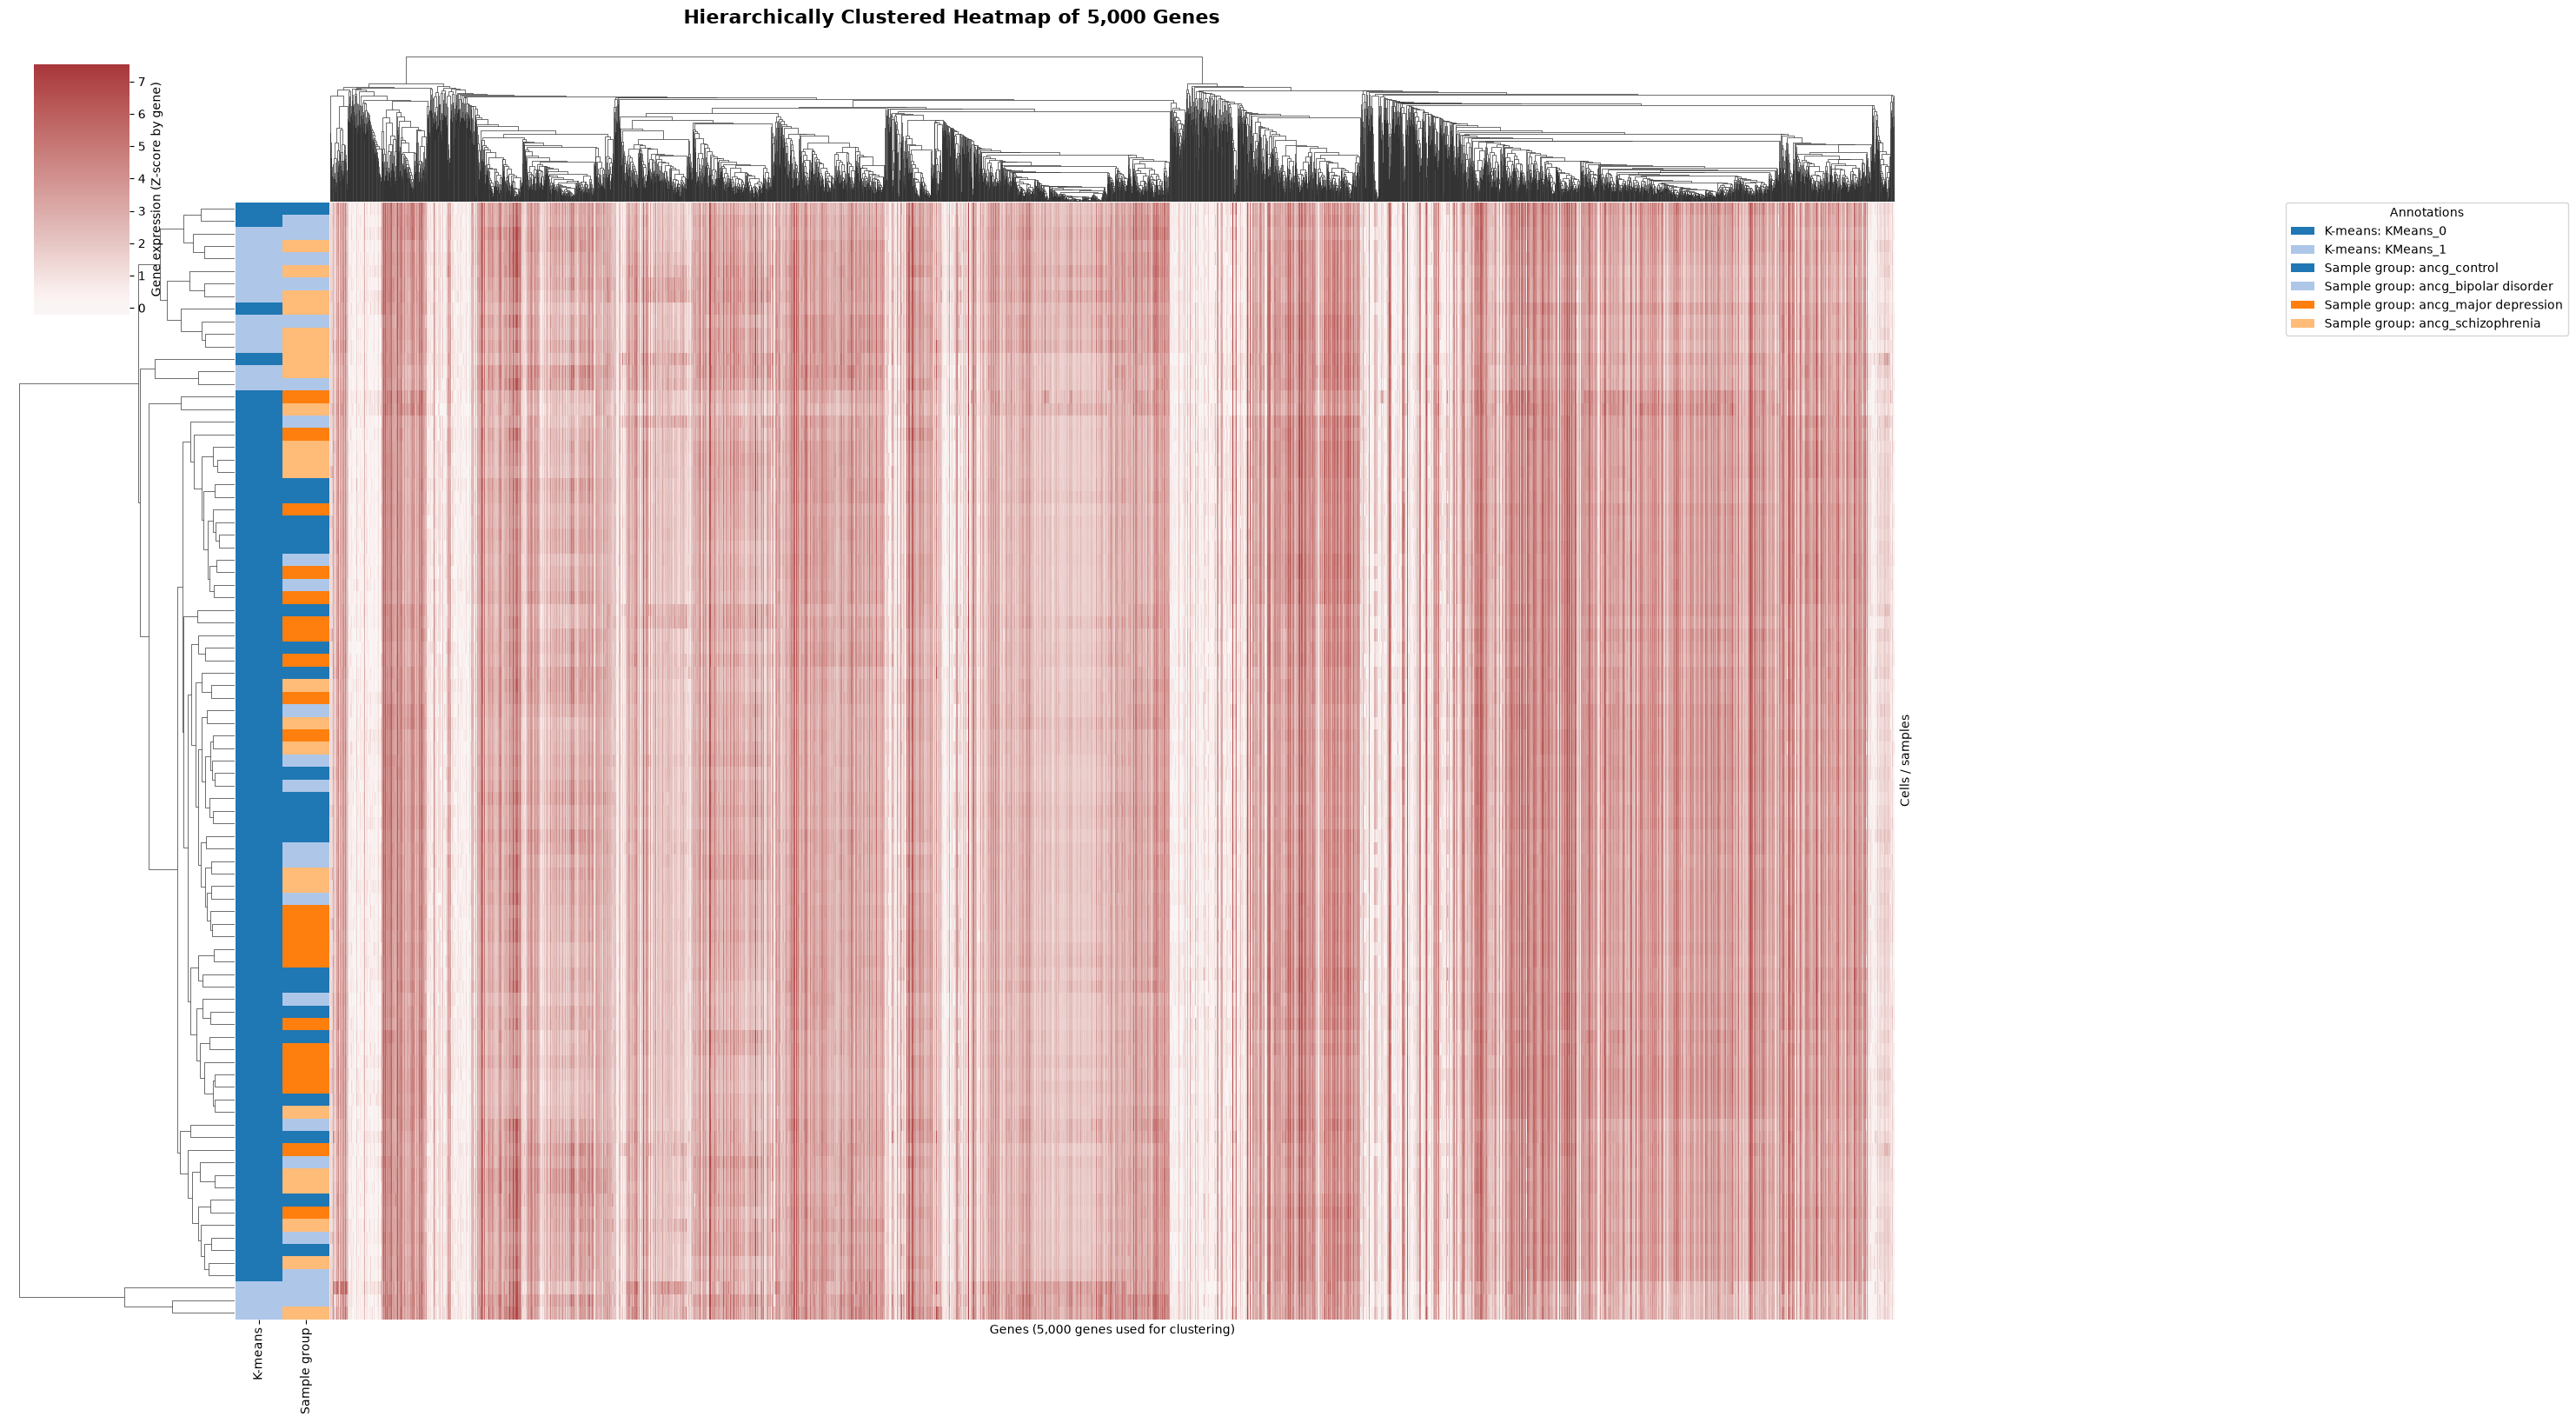

In [43]:
g = sns.clustermap(
    X,
    cmap="vlag",
    center=0,
    row_cluster=True,       # Cell/sample dendrogram
    col_cluster=True,       # Gene dendrogram
    method="average",       # Hierarchical linkage method
    metric="correlation",   # Cluster cells/genes by expression pattern
    row_colors=row_color_data,
    xticklabels=False,      # 5,000 gene names would be unreadable
    yticklabels=False,      # Often too many cell names to show
    figsize=(22, 16),
    dendrogram_ratio=(0.12, 0.12),
    colors_ratio=0.025,
    cbar_kws={
        "label": "Gene expression (Z-score by gene)"
    }
)

g.ax_heatmap.set_xlabel("Genes (5,000 genes used for clustering)")
g.ax_heatmap.set_ylabel("Cells / samples")

g.fig.suptitle(
    "Hierarchically Clustered Heatmap of 5,000 Genes",
    y=1.02,
    fontsize=16,
    fontweight="bold"
)

g.ax_row_colors.set_xticks(
    np.arange(len(row_color_data.columns)) + 0.5
)
g.ax_row_colors.set_xticklabels(
    row_color_data.columns,
    rotation=90,
    fontsize=10
)

legend_handles = []

for column, color_map in annotation_color_maps.items():
    for category, color in color_map.items():
        legend_handles.append(
            Patch(
                facecolor=color,
                edgecolor="none",
                label=f"{column}: {category}"
            )
        )

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Annotations",
    bbox_to_anchor=(1.25, 1),
    loc="upper left",
    borderaxespad=0
)

plt.show()

## Statistics

In [33]:
contingency=pd.crosstab(
    annotations["Sample group"],
    annotations["K-means"],
    rownames=["Group"],
    colnames=["cluster"])

In [34]:
contingency

cluster,0,1
Group,,
ancg_bipolar disorder,15,7
ancg_control,22,0
ancg_major depression,22,0
ancg_schizophrenia,16,7


In [35]:
chi2, p_value, dof, expected = chi2_contingency(contingency)

In [36]:
results=[]
results.append({
        "Method": "K-means",
        "Genes used": 5000,
        "Chi-square": chi2,
        "df": dof,
        "p-value": p_value,
        "Number of clusters": contingency.shape[1],
        "Minimum expected count": expected.min(),
        "Percent expected < 5": 100 * (expected < 5).mean()
    })
chi2_results=pd.DataFrame(results)

In [37]:
chi2_results

,Method,Genes used,Chi-square,df,p-value,Number of clusters,Minimum expected count,Percent expected < 5
0,K-means,5000,16.260382,3,0.001003,2,3.460674,50.0


In [52]:
chi2_results

,Method,Genes used,Chi-square,df,p-value,Number of clusters,Minimum expected count,Percent expected < 5
0,K-means,5000,16.260382,3,0.001003,2,3.460674,50.0


In [31]:
annotations=pd.DataFrame(
    {
        "K-means": best_labels_5000,
        "Sample group": keep['refinebio_subject']
    },
    index=X.index
)

In [39]:
ari

,10,100,1000,5000,10000
10,1.000000,1.000000,1.000000,0.180235,1.000000
100,1.000000,1.000000,1.000000,0.180235,1.000000
1000,1.000000,1.000000,1.000000,0.180235,1.000000
5000,0.180235,0.180235,0.180235,1.000000,0.180235
10000,1.000000,1.000000,1.000000,0.180235,1.000000


In [22]:
from sklearn.metrics import silhouette_score, adjusted_rand_score

GENE_COUNTS = [10, 100, 1000, 5000, 10000]
for n in GENE_COUNTS:
    if n != 5000:
        kmeans=KMeans(n_clusters=k,
                      random_state=0,
                      n_init="auto")
        lab=kmeans.fit_predict(X)
        labels[f"g{n}_k2"] = lab

gene_cols = [f"g{n}_k2" for n in GENE_COUNTS]
for c in gene_cols:
    tab = pd.crosstab(labels[c], keep.dx).reindex(columns=DX_ORDER, fill_value=0)
    print(f"\n{c}  ARI vs 5,000 genes = {adjusted_rand_score(labels['g5000_k2'], labels[c]):.2f}")
    print(tab.rename(columns=DX_NAME).to_string())

ari = pd.DataFrame([[adjusted_rand_score(labels[a], labels[b]) for b in gene_cols] for a in gene_cols],
                   index=GENE_COUNTS, columns=GENE_COUNTS)
ari.round(2)


g10_k2  ARI vs 5,000 genes = 0.18
dx      Control  Depression  Bipolar  Schizophrenia
g10_k2                                             
0             8           6        3              3
1             5           4        8              9
2             0           0        1              0
3             9          12        5              6
4             0           0        5              5

g100_k2  ARI vs 5,000 genes = 0.18
dx       Control  Depression  Bipolar  Schizophrenia
g100_k2                                             
0              8           6        3              3
1              5           4        8              9
2              0           0        1              0
3              9          12        5              6
4              0           0        5              5

g1000_k2  ARI vs 5,000 genes = 0.18
dx        Control  Depression  Bipolar  Schizophrenia
g1000_k2                                             
0               8           6        3           

,10,100,1000,5000,10000
10,1.00,1.00,1.00,0.18,1.00
100,1.00,1.00,1.00,0.18,1.00
1000,1.00,1.00,1.00,0.18,1.00
5000,0.18,0.18,0.18,1.00,0.18
10000,1.00,1.00,1.00,0.18,1.00


In [27]:
GENE_COUNTS = [10, 100, 1000, 5000, 10000]
from itertools import combinations
from statsmodels.stats.multitest import multipletests

def chi_row(name, kind, a, b):
    ct = pd.crosstab(a, b)
    chi2, p, dof, exp = chi2_contingency(ct)
    return {"comparison": name, "type": kind, "chi2": chi2, "df": dof, "p_value": p,
            "ARI": adjusted_rand_score(a, b), "min_expected": exp.min(),
            "pct_expected_below_5": 100 * (exp < 5).mean()}

rows = []
for a, b in combinations(GENE_COUNTS, 2):
    rows.append(chi_row(f"{a:,} vs {b:,} genes (k=2)", "gene count vs gene count",
                        labels[f"g{a}_k2"], labels[f"g{b}_k2"]))
for a, b in combinations(KS, 2):
    rows.append(chi_row(f"k={a} vs k={b} (5,000 genes)", "k vs k (nested, trivially significant)",
                        labels[f"g5000_k{a}"], labels[f"g5000_k{b}"]))
versions = [f"g{n}_k2" for n in GENE_COUNTS] + [f"g5000_k{k}" for k in KS[1:]]
for v in versions:
    n, k = v[1:].split("_k")
    rows.append(chi_row(f"{int(n):,} genes, k={k} vs diagnosis", "clusters vs diagnosis",
                        labels[v], keep.dx))

chisq = pd.DataFrame(rows)
chisq.insert(5, "p_adj_BH", multipletests(chisq.p_value, method="fdr_bh")[1])
chisq["method"] = "hierarchical (Ward)"
chisq.to_csv("results/a3_hclust_chisq_table.tsv", sep="\t", index=False)

with pd.option_context("display.width", 200, "display.max_colwidth", 40):
    print(chisq.drop(columns=["method"]).to_string(
        formatters={"chi2": "{:.2f}".format, "p_value": "{:.2e}".format, "p_adj_BH": "{:.2e}".format,
                    "ARI": "{:.2f}".format, "min_expected": "{:.2f}".format,
                    "pct_expected_below_5": "{:.0f}".format}))

                        comparison                                    type   chi2  df  p_value p_adj_BH  ARI min_expected pct_expected_below_5
0            10 vs 100 genes (k=2)                gene count vs gene count 356.00  16 5.80e-66 2.32e-65 1.00         0.01                   68
1          10 vs 1,000 genes (k=2)                gene count vs gene count 356.00  16 5.80e-66 2.32e-65 1.00         0.01                   68
2          10 vs 5,000 genes (k=2)                gene count vs gene count  68.98   4 3.73e-14 6.39e-14 0.18         0.16                   50
3         10 vs 10,000 genes (k=2)                gene count vs gene count 356.00  16 5.80e-66 2.32e-65 1.00         0.01                   68
4         100 vs 1,000 genes (k=2)                gene count vs gene count 356.00  16 5.80e-66 2.32e-65 1.00         0.01                   68
5         100 vs 5,000 genes (k=2)                gene count vs gene count  68.98   4 3.73e-14 6.39e-14 0.18         0.16                   50

### 4

In [25]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram, set_link_color_palette

total_annotations=[]
names=[]

#k=2 to k=5
KS = [2, 3, 4, 5]
avg_tree = linkage(X.values, method="average", metric="correlation")
for k in KS:
    lab = fcluster(avg_tree, k, "maxclust")
    annotations=pd.DataFrame(
        {
            "K-means": lab,
            "Sample group": keep['refinebio_subject']
        },
        index=X.index
    )
    total_annotations.append(annotations)
    names.append(f"k={k}")

#genes 10,100,1000,10000
n_genes=[10, 100, 1000, 10000]
cluster_labels=[]
for n in n_genes:
    top = log_expr.var(axis=1).sort_values(ascending=False).index[:n]
    X = log_expr.loc[top].T
    print(X.shape)

    lab = fcluster(linkage(X.values, method="ward"), 2, "maxclust")
    annotations=pd.DataFrame(
        {
            "K-means": lab,
            "Sample group": keep['refinebio_subject']
        },
        index=X.index
    )
    total_annotations.append(annotations)
    names.append(f"{n} genes")

(89, 10)
(89, 100)
(89, 1000)
(89, 10000)


In [26]:
results=[]
for name, annotation in zip(names, total_annotations):
    contingency=pd.crosstab(
    annotation["Sample group"],
    annotation["K-means"],
    rownames=["Group"],
    colnames=["cluster"])

    chi2, p_value, dof, expected = chi2_contingency(contingency)
    results.append({
        "Method": name,
        "Chi-square": chi2,
        "df": dof,
        "p-value": p_value,
        "Number of clusters": contingency.shape[1],
        "Minimum expected count": expected.min(),
        "Percent expected < 5": 100 * (expected < 5).mean()
    })
chi2_results=pd.DataFrame(results)
chi2_results.insert(5, "p_adj_BH", multipletests(chi2_results['p-value'], method="fdr_bh")[1])

In [27]:
chi2_results

,Method,Chi-square,df,p-value,Number of clusters,p_adj_BH,Minimum expected count,Percent expected < 5
0,k=2,3.812299,3,0.282459,2,0.322810,0.741573,50.000000
1,k=3,5.131469,6,0.527065,3,0.527065,0.247191,66.666667
2,k=4,21.182729,9,0.011863,4,0.023727,0.247191,75.000000
3,k=5,21.800033,12,0.039823,5,0.063717,0.247191,80.000000
4,10 genes,4.451615,3,0.216647,2,0.288863,9.887640,0.000000
5,100 genes,11.711594,3,0.008439,2,0.022505,3.213483,50.000000
6,1000 genes,15.181492,3,0.001668,2,0.006672,3.213483,50.000000
7,10000 genes,15.181492,3,0.001668,2,0.006672,3.213483,50.000000
